# HLCA Datset (core) Investigation

## Load dataset

In [2]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.cellxgene import get_cxg_url
from utils.io import read_anndata


# url = get_cxg_url(
#     collection_id="6f6d381a-7701-4781-935c-db10d30de293",
#     dataset_id="066943a2-fdac-4b29-b348-40cede398e4e"
# )

dataset_name = 'Sikkema2023'
file_path = f'data/{dataset_name}.h5ad'

# if not Path(file_path).exists():
#     !curl {url} > {file_path}


adata = read_anndata(
    file_path,
    X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "X", store as "X"...


/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


## Dataset Complexity
### Tissues

In [3]:
adata.obs["tissue"].unique()

['lung parenchyma', 'respiratory airway', 'nose']
Categories (3, object): ['nose', 'respiratory airway', 'lung parenchyma']

Sample size of the tissues:

In [4]:
sample_size = adata.obs["tissue"].value_counts()
sample_size

tissue
lung parenchyma       333468
respiratory airway    173197
nose                   78279
Name: count, dtype: int64

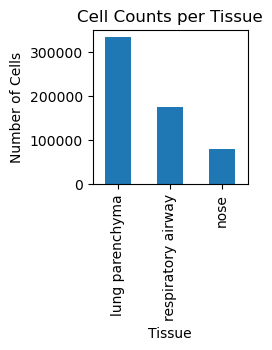

In [5]:
plt.figure(figsize=(2, 2))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Tissue")
plt.xlabel("Tissue")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout
plt.show()

### Number of Cells and Genes

In [6]:
adata

AnnData object with n_obs × n_vars = 584944 × 27957
    obs: 'suspension_type', 'donor_id', 'is_primary_data', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'cause_of_death', 'dataset', 'entropy_dataset_leiden_3', 'entropy_original_ann_level_1_leiden_3', 'entropy_original_ann_level_2_clean_leiden_3', 'entropy_original_ann_level_3_clean_leiden_3', 'entropy_subject_ID_leiden_3', 'fresh_or_frozen', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'n_genes_detected', 'original_ann_highest_res', 'original_ann_level_1', 'original_ann_level_2', 'origi

### Number of Cell Types

In [7]:
adata.obs["cell_type"].nunique()

50

## Batch Complexity
### Number of Batches

According to the paper, batch = dataset

In [8]:
adata.obs["dataset"].nunique()

14

### Batch Size Imbalance

In [9]:
batch_size = adata.obs["dataset"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")

Mean batch size: 41781.71
Standard deviation: 31937.15
Minimum batch size: 2921
Maximum batch size: 121894


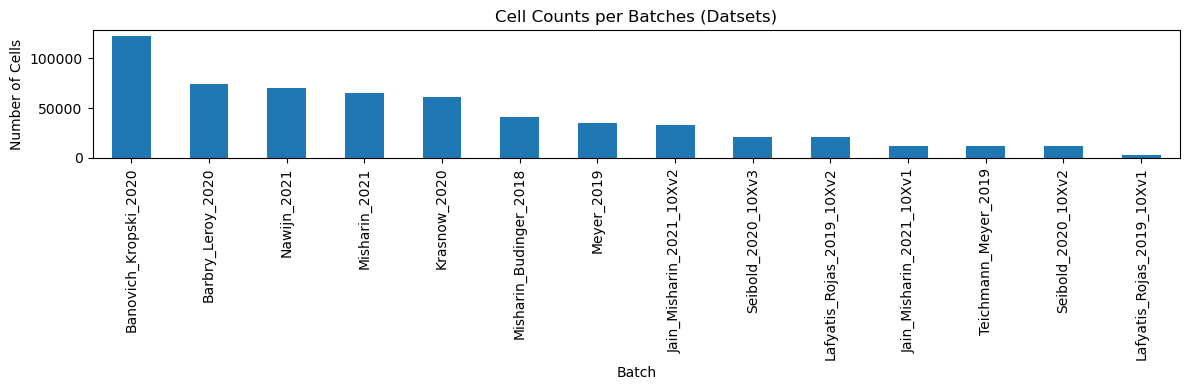

In [10]:
plt.figure(figsize=(12, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (Datsets)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Nested Batches

In [11]:
adata.obs[['dataset', 'donor_id']].drop_duplicates().value_counts('dataset')

dataset
Banovich_Kropski_2020        38
Barbry_Leroy_2020            10
Nawijn_2021                  10
Misharin_Budinger_2018        8
Seibold_2020_10Xv3            8
Seibold_2020_10Xv2            6
Teichmann_Meyer_2019          6
Jain_Misharin_2021_10Xv2      5
Lafyatis_Rojas_2019_10Xv2     4
Krasnow_2020                  3
Meyer_2019                    3
Jain_Misharin_2021_10Xv1      2
Lafyatis_Rojas_2019_10Xv1     2
Misharin_2021                 2
Name: count, dtype: int64

In [12]:
adata.obs[['dataset', 'donor_id']].drop_duplicates().value_counts('donor_id')

donor_id
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747lafy_donor_6       1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_4837472020-3173-NC002    1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_4837472020-3173-NC003    1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747VUHD84             1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747VUHD85             1
                                                                                       ..
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_4837472020-3173-NC008    1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747284C               1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747290B               1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747292B               1
homosapiens_None_2023_None_sikkemalisa_001_d10_1101_2022_03_10_483747296C               1
N

dataset:donor is 1:N -> nested bathches?

### Number and Size of Samples

In [13]:
adata.obs["sample"].nunique()

166

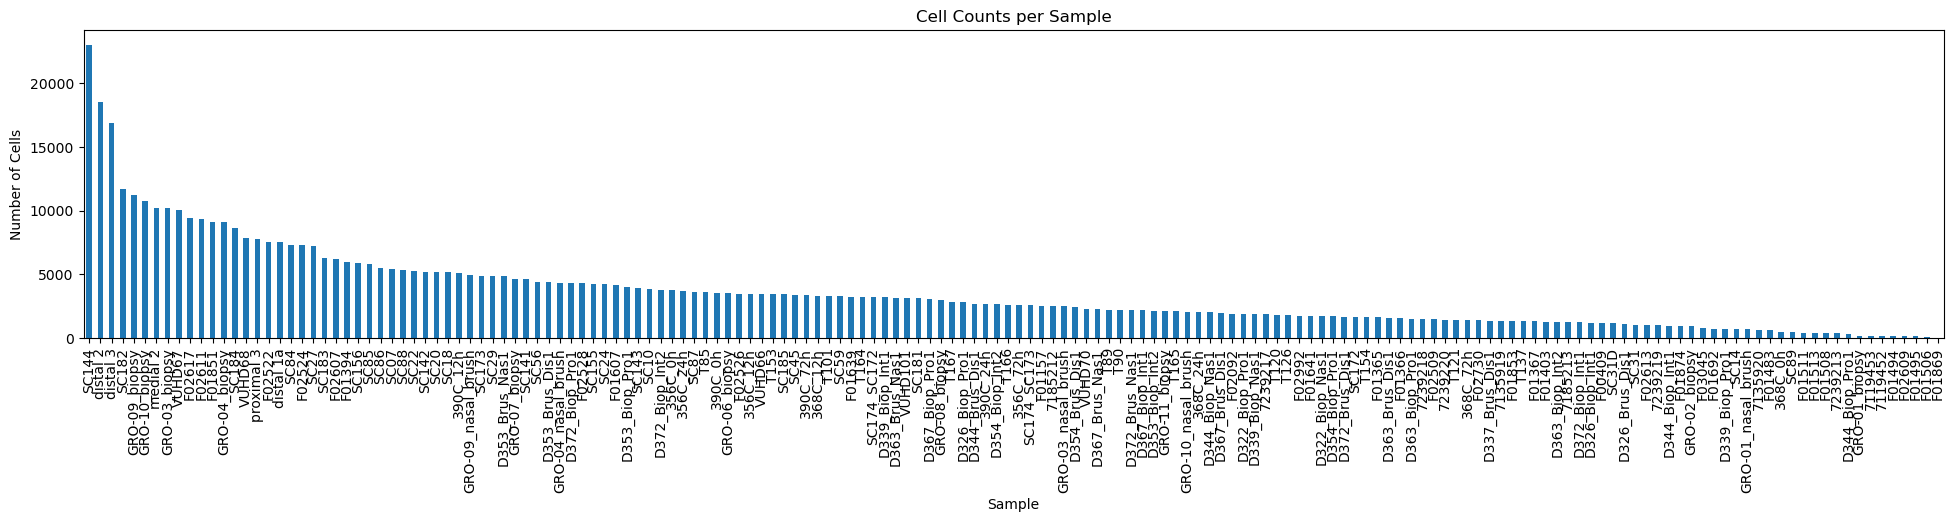

In [14]:
sample_size = adata.obs["sample"].value_counts()

plt.figure(figsize=(24, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.show()

### Number of Donors

In [15]:
adata.obs["donor_id"].nunique()

107

### Number of Cohorts

In [19]:
adata.obs["dataset"].nunique()

14

## Annotation Quality
### Resolution of Annotation

In [20]:
adata.var["feature_name"]

ENSG00000000003             TSPAN6
ENSG00000000005               TNMD
ENSG00000000419               DPM1
ENSG00000000457              SCYL3
ENSG00000000460           C1orf112
                        ...       
ENSG00000283078    ENSG00000283078
ENSG00000283103    ENSG00000283103
ENSG00000283117            MGC4859
ENSG00000283118    ENSG00000283118
ENSG00000283125    ENSG00000283125
Name: feature_name, Length: 27957, dtype: category
Categories (27944, object): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', ..., 'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3']

In [21]:
marker_genes_epithelial = {
    "Basal resting": ["TP63", "KRT5", "KRT15"],
    "Basal proliferating": ["MKI67", "TOP2A"],
    "Suprabasal": ["KRT4", "KRT13"],
    "Multiciliated (nasal/tracheal)": ["FOXJ1", "TPPP3"],
    "Multiciliated (nasal)": ["PIFO", "DNAH5"],
    "Multiciliated (tracheal)": ["CCDC153"],
    "Ionocyte": ["FOXI1", "ATP6V1B1"],
    "Goblet (nasal/tracheal)": ["MUC5AC", "SPDEF"],
    "Goblet (nasal)": ["BPIFB1"],
    "Goblet (tracheal)": ["AGR2"],
    "Club (nasal/tracheal)": ["SCGB1A1", "SCGB3A1"],
    "Club (nasal)": ["CYP2F1"],
    "Club (tracheal)": ["KRT7"],
    "Terminal bronchiole": ["SCGB3A2", "SFTPB"],
    "Proximal secretory": ["BPIFA1"],
    "Distal secretory": ["MUC5B", "LTF"],
    "Goblet (glandular)": ["TFF3"],
    "SMG acinar serous": ["LYZ", "LTF"],
    "SMG acinar mucous": ["BPIFB1"],
    "SMG duct": ["SLC5A5"],
    "SMG serous cap": ["LTF", "BPIFA1"],
    "SMG serous duct": ["BPIFB1", "LYZ"],
    "SMG ionocyte": ["FOXI1"],
    "AT2": ["SFTPC", "SFTPA1"],
    "AT2 proliferating": ["TOP2A", "MKI67"]
}

marker_genes_immune = {
    "Hematopoietic stem cells": ["CD34", "AVP"],
    "B cells": ["CD79A", "MS4A1"],
    "Plasma cells": ["MZB1", "SDC1"],
    "CD8 T cells": ["CD8A", "CD8B"],
    "CD4 T cells": ["CD4", "IL7R"],
    "T cells proliferating": ["MKI67", "TOP2A"],
    "NK cells": ["NKG7", "GNLY"],
    "ILC": ["KIT"],
    "DC1": ["CLEC9A", "BATF3"],
    "DC2": ["CD1C", "FCER1A"],
    "Migratory DCs": ["CCR7", "LAMP3"],
    "Plasmacytoid DCs": ["IL3RA", "LILRA4"],
    "Alveolar macrophages": ["MARCO", "FABP4"],
    "Alveolar Mph (CCL3+)": ["CCL3", "IL1B"],
    "Alveolar Mph proliferating": ["TOP2A", "MKI67"],
    "Interstitial Mph": ["LYVE1", "CD163"],
    "Monocytes": ["FCN1", "S100A8"],
    "Classical monocytes": ["S100A8", "S100A9"],
    "Non-classical monocytes": ["FCGR3A"],
    "Mast cells": ["TPSAB1", "KIT"]
}

marker_genes_stromal = {
    "Peribronchial fibroblasts": ["COL6A3", "POSTN"],
    "Adventitial fibroblasts": ["PI16", "COL6A1"],
    "Alveolar fibroblasts": ["NPNT", "ADAMTS1"],
    "Fibroblasts": ["PDGFRA"],
    "Subpleural fibroblasts": ["HAS1"],
    "Smooth muscle": ["ACTA2", "MYH11"],
    "Smooth muscle-FN1/ID3": ["FN1", "ID3"],
    "SM activated stress response": ["FOS", "JUN"],
    "Mesothelium": ["WT1", "UPK3B"]
}

marker_genes_endothelial = {
    "Endothelial": ["PECAM1", "VWF"],
    "EC arterial": ["EFNB2", "HEY1"],
    "EC aerocyte capillary": ["EDNRB", "CA4"],
    "EC general capillary": ["GPIHBP1", "FABP4"],
    "EC venous capillary": ["ACKR1"],
    "EC venous (systemic)": ["SELE", "VCAM1"],
    "EC venous (pulmonary)": ["DARC"],
    "Lymphatic EC marker": ["PROX1", "PDPN"],
    "Lymphatic EC mature": ["CLDN5"],
    "Lymphatic EC proliferating": ["MKI67", "TOP2A"],
    "Lymphatic EC differentiating": ["CCBE1"]
}

# https://www.nature.com/articles/s41591-023-02327-2/figures/9

In [22]:
adata.var_names

Index(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938',
       'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084',
       'ENSG00000001167',
       ...
       'ENSG00000283052', 'ENSG00000283063', 'ENSG00000283064',
       'ENSG00000283071', 'ENSG00000283075', 'ENSG00000283078',
       'ENSG00000283103', 'ENSG00000283117', 'ENSG00000283118',
       'ENSG00000283125'],
      dtype='object', length=27957)

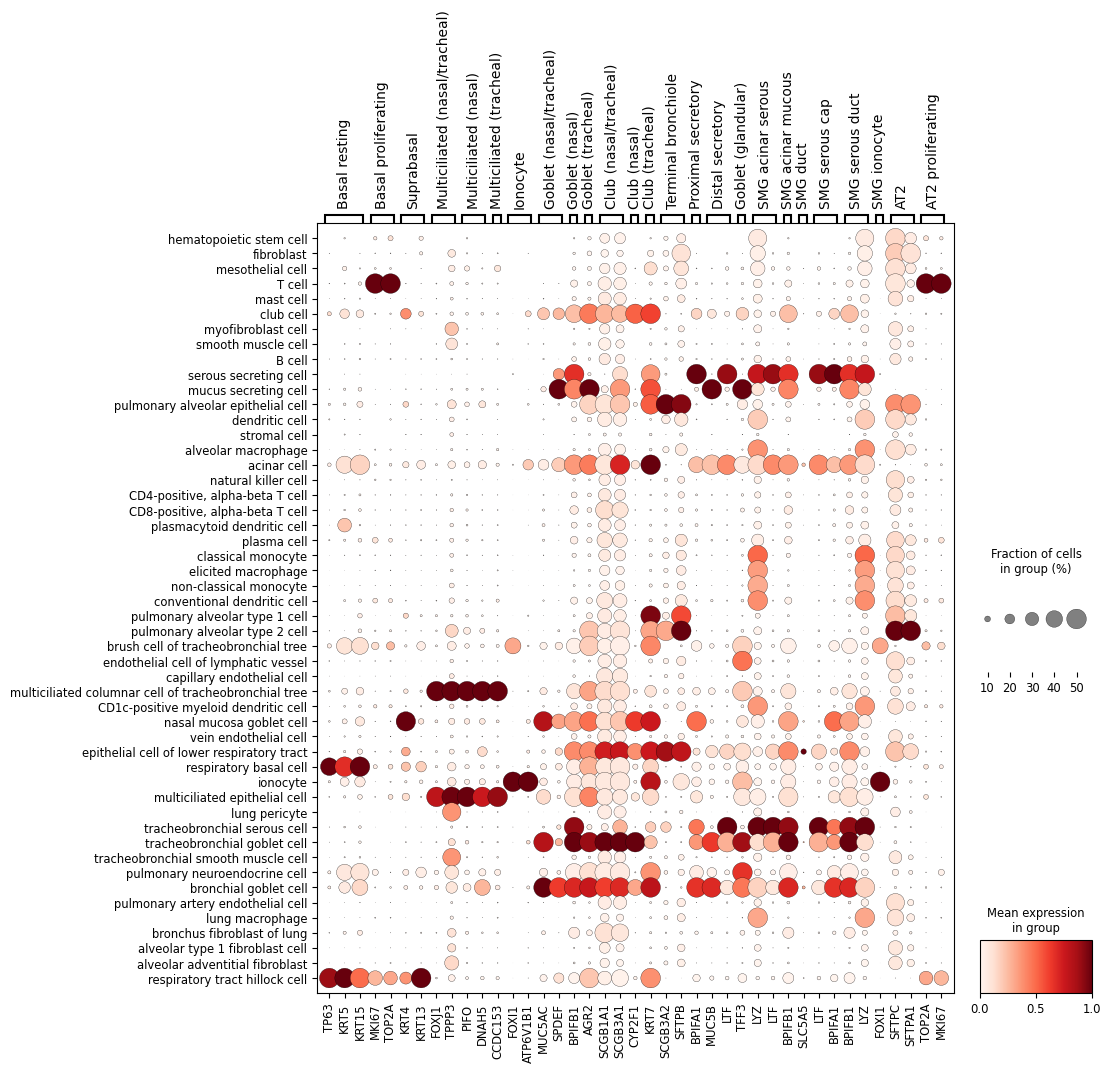

In [25]:
sc.pl.dotplot(
    adata,
    var_names=marker_genes_epithelial,
    groupby='cell_type',
    gene_symbols='feature_name',
    standard_scale='var',
    dot_max=0.5,
    figsize=(10, 10)
)

Q: How to interpret?

### Granularity of Cell Types

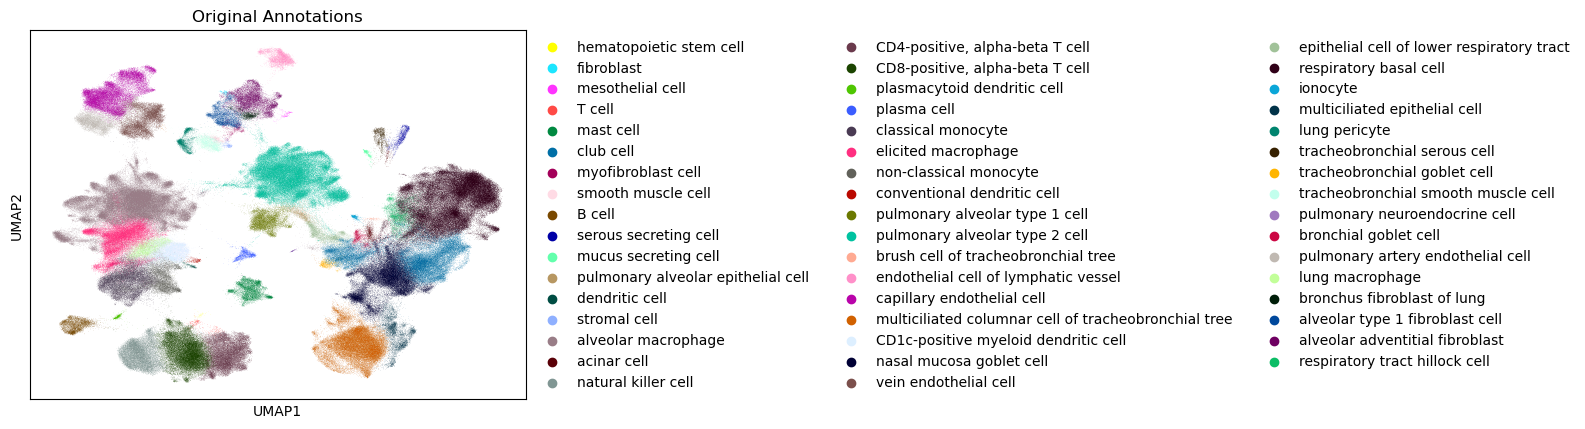

In [26]:
sc.pl.umap(adata, color='cell_type', title='Original Annotations')

In [43]:
adata.obs["reannotation_type"]

GCGACCATCCCTAACC_SC22      Correctly annotated
P2_1_GCGCAACCAGTTAACC      Correctly annotated
GCTCTGTAGTGCTGCC_SC27      Correctly annotated
P2_8_TTAGGACGTTCAGGCC           Underannotated
CTTGATTGTCAGTTTG_T164             Misannotated
                                  ...         
ACCTTTACATTAACCG_T120             Misannotated
CATTATCTCCATGAAC_F01639           Misannotated
AGGCCGTGTGTGACCC-SC56      Correctly annotated
CGATGGCAGCAGGCTA-1-2            Underannotated
AATCGGTGTCGGCACT-1-4            Underannotated
Name: reannotation_type, Length: 584944, dtype: category
Categories (3, object): ['Correctly annotated', 'Misannotated', 'Underannotated']

## Metadata Completeness
### Anatomical Location

### Existence of Embeddings

In [46]:
adata.obsm

AxisArrays with keys: X_scanvi_emb, X_umap